In [ ]:
#Carga de las Bibliotecas
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Carga del archivo CSV
df=pd.read_csv('hotel_bookings.csv')

In [ ]:
#Mostrar contenido del dataset
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [ ]:
#Columnas o atributos que conforman la data
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [ ]:
#Descripción de la naturaleza y tipo de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
#Identificación de valores nulos por atributo
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


# **Imputación de valores nulos acorde al contexto y caso**

In [ ]:

#definición de la funcion para limpiar los nulos en atributos numericos
def delenum(lista):
  for item in lista:
    media=df[item].mean()
    df[item]=df[item].fillna(media)
#definición de funcion para limpiar los nulos en atributos numericos
def deleobject(lista):
  for item in lista:
    moda=df[item].mode()[0]
    df[item]=df[item].fillna(moda)

delenum(['lead_time','arrival_date_year'])

In [ ]:
lista=['country']
deleobject(lista)

In [ ]:
df.children.fillna(0,inplace=True) #reemplaza el null en la columna children por 0

In [ ]:
df.country.fillna("UNKNOWN",inplace=True)

In [ ]:
df.dropna(axis=1,inplace=True)

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


# **# Estadística descriptiva después de la limpieza de nulos**

In [1]:
df.describe( )

NameError: name 'df' is not defined

# **Identificación y limpieza de Outlier**

In [ ]:
# Usar la función vectorizada
def find_anomalies_vectorized(data):
    first_col = data.iloc[:, 0]
    data_mean = first_col.mean()
    data_std = first_col.std()
    anomaly_cut_off = data_std * 2
    lower_limit = data_mean - anomaly_cut_off
    upper_limit = data_mean + anomaly_cut_off
    print("Límite inferior:", lower_limit)
    print("Límite superior:", upper_limit)
    mask = (first_col < lower_limit) | (first_col > upper_limit)
    anomalies = first_col.index[mask].tolist()
    return anomalies

#Se selecciona la variable 'adults'  debido a que se observa en las estádistica descriptiva que el valos máximo esta muy
#alejado de la media

# Ejecutar la función
anomalies = find_anomalies_vectorized(df[['adults']])
print("Índices de anomalías:", anomalies)

# Ver el contenido de los índices que se van a borrar
print("\nContenido de las filas que se eliminarán:")
print(df.loc[anomalies])

# Eliminar filas con anomalías
data_clean = df.drop(index=anomalies)
print("\nDataFrame limpio:")
print(data_clean)
df=data_clean

Límite inferior: 0.6978813862018627
Límite superior: 3.0149253815341286
Índices de anomalías: [125, 354, 1023, 1539, 1587, 1643, 1752, 1884, 1917, 1962, 2003, 2164, 2173, 2224, 2228, 2229, 2231, 2409, 2417, 2418, 2419, 3181, 3684, 3708, 4127, 6116, 7966, 8052, 9376, 11048, 11584, 12083, 13016, 13027, 15995, 16151, 16313, 16626, 18234, 22383, 22828, 26215, 26216, 26306, 26573, 26700, 27323, 27351, 27748, 28085, 28094, 31765, 32029, 32827, 34787, 34849, 34855, 37459, 39477, 39931, 40392, 40922, 40984, 41020, 41048, 41056, 41446, 41952, 42452, 42591, 42871, 42934, 45158, 46132, 46150, 46186, 46196, 46220, 46488, 46546, 46559, 46646, 46648, 46655, 46688, 46740, 47046, 47074, 47110, 47121, 47133, 47166, 47175, 47180, 47201, 47434, 47444, 47568, 47817, 48224, 48233, 48455, 48508, 48630, 48775, 48846, 48900, 49007, 49015, 49264, 49403, 50162, 50701, 50702, 51330, 51585, 52156, 53334, 53641, 54000, 54025, 54037, 54047, 54093, 54122, 54136, 54140, 54224, 54254, 54410, 54472, 54479, 54595, 54726

In [ ]:
data_clean.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,118909.000000,118909.000000,118909.000000,118909.000000,118909.000000,118909.000000,118909.000000,118909.000000,118909.000000,118909.000000,118909.000000,118909.000000,118909.000000,118909.000000,118909.000000,118909.000000,118909.000000,118909.000000
mean,0.370729,104.053259,2016.156481,27.161165,15.797030,0.926894,2.499020,1.858505,0.100480,0.007947,0.031545,0.087386,0.137416,0.218301,2.327090,101.971777,0.062611,0.570638
std,0.483002,106.875519,0.707685,13.600231,8.781454,0.995353,1.897974,0.475175,0.390319,0.097462,0.174786,0.845963,1.500005,0.637568,17.619873,50.378840,0.245470,0.792282
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.500000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.970000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,3.000000,10.000000,10.000000,1.000000,26.000000,72.000000,18.000000,391.000000,5400.000000,8.000000,5.000000


# **Análisis de los datos**

In [ ]:
#Top de registros por paises
df.country.value_counts()

,count
country,
PRT,48867
GBR,12098
FRA,10374
ESP,8544
DEU,7270
...,...
MRT,1
KIR,1
SDN,1


# **Selecciona las columnas útiles, acorde al contexto o acorde a la investigación**

In [ ]:
df=df[['hotel','arrival_date_year','is_canceled',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country','is_repeated_guest', 'reserved_room_type',
       'assigned_room_type', 'booking_changes','days_in_waiting_list',
       'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status']] # escoge columnas especificas

In [ ]:
df

,hotel,arrival_date_year,is_canceled,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,is_repeated_guest,reserved_room_type,assigned_room_type,booking_changes,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,Resort Hotel,2015,0,July,27,1,0,0,2,0.0,...,0,C,C,3,0,Transient,0.00,0,0,Check-Out
1,Resort Hotel,2015,0,July,27,1,0,0,2,0.0,...,0,C,C,4,0,Transient,0.00,0,0,Check-Out
2,Resort Hotel,2015,0,July,27,1,0,1,1,0.0,...,0,A,C,0,0,Transient,75.00,0,0,Check-Out
3,Resort Hotel,2015,0,July,27,1,0,1,1,0.0,...,0,A,A,0,0,Transient,75.00,0,0,Check-Out
4,Resort Hotel,2015,0,July,27,1,0,2,2,0.0,...,0,A,A,0,0,Transient,98.00,0,1,Check-Out
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,2017,0,August,35,30,2,5,2,0.0,...,0,A,A,0,0,Transient,96.14,0,0,Check-Out
119386,City Hotel,2017,0,August,35,31,2,5,3,0.0,...,0,E,E,0,0,Transient,225.43,0,2,Check-Out
119387,City Hotel,2017,0,August,35,31,2,5,2,0.0,...,0,D,D,0,0,Transient,157.71,0,4,Check-Out
119388,City Hotel,2017,0,August,35,31,2,5,2,0.0,...,0,A,A,0,0,Transient,104.40,0,0,Check-Out


# **Busca elementos clave en los datos**

In [ ]:
df['customer_type'].unique()

array(['Transient', 'Contract', 'Transient-Party', 'Group'], dtype=object)

<Axes: xlabel='customer_type'>

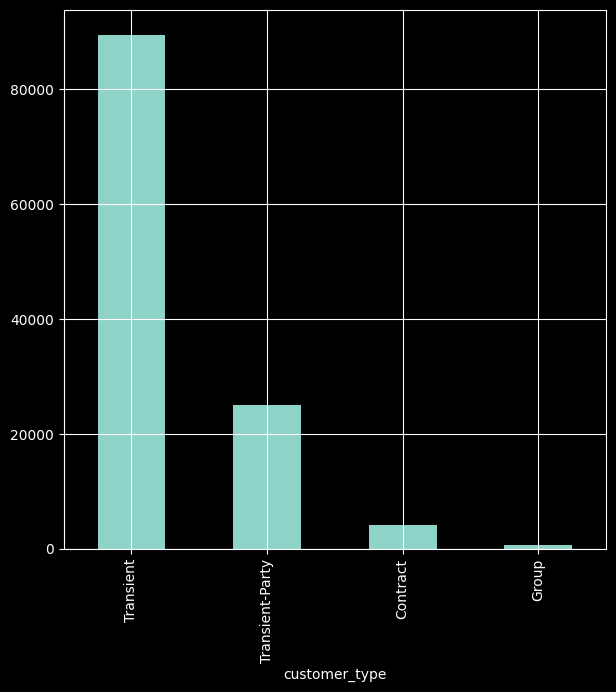

In [ ]:
df['customer_type'].value_counts().plot(kind='bar',figsize=(7,7),grid=True)
#los clientes transient son los de mayor demanda

In [ ]:
dec=df.describe(include="object").T
dec

,count,unique,top,freq
hotel,118909,2,City Hotel,78909
arrival_date_month,118909,12,August,13812
meal,118909,5,BB,91949
country,118909,177,PRT,48867
reserved_room_type,118909,9,A,85850
assigned_room_type,118909,11,A,73971
customer_type,118909,4,Transient,89278
reservation_status,118909,3,Check-Out,74826


In [ ]:
df.adr.mean()#promedio de tasa diaria

np.float64(101.97177665273443)

<Axes: xlabel='hotel'>

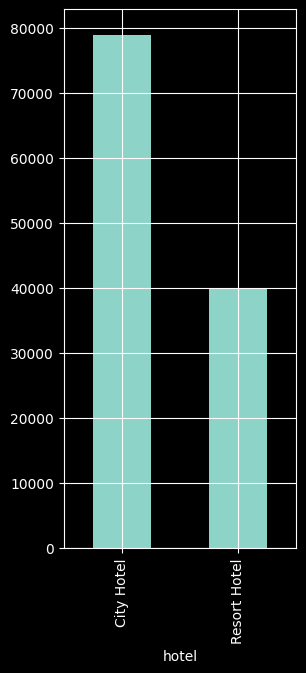

In [ ]:
df.hotel.value_counts().plot(kind='bar',figsize=(3,7),grid=True)
#comparación entre tipos de hotel

In [ ]:
month=df.groupby('arrival_date_month').count()#agrupa la data por mes de llegada
month

,hotel,arrival_date_year,is_canceled,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,is_repeated_guest,reserved_room_type,assigned_room_type,booking_changes,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
arrival_date_month,,,,,,,,,,,,,,,,,,,,,
April,11054,11054,11054,11054,11054,11054,11054,11054,11054,11054,...,11054,11054,11054,11054,11054,11054,11054,11054,11054,11054
August,13812,13812,13812,13812,13812,13812,13812,13812,13812,13812,...,13812,13812,13812,13812,13812,13812,13812,13812,13812,13812
December,6732,6732,6732,6732,6732,6732,6732,6732,6732,6732,...,6732,6732,6732,6732,6732,6732,6732,6732,6732,6732
February,8032,8032,8032,8032,8032,8032,8032,8032,8032,8032,...,8032,8032,8032,8032,8032,8032,8032,8032,8032,8032
January,5903,5903,5903,5903,5903,5903,5903,5903,5903,5903,...,5903,5903,5903,5903,5903,5903,5903,5903,5903,5903
July,12598,12598,12598,12598,12598,12598,12598,12598,12598,12598,...,12598,12598,12598,12598,12598,12598,12598,12598,12598,12598
June,10913,10913,10913,10913,10913,10913,10913,10913,10913,10913,...,10913,10913,10913,10913,10913,10913,10913,10913,10913,10913
March,9747,9747,9747,9747,9747,9747,9747,9747,9747,9747,...,9747,9747,9747,9747,9747,9747,9747,9747,9747,9747
May,11758,11758,11758,11758,11758,11758,11758,11758,11758,11758,...,11758,11758,11758,11758,11758,11758,11758,11758,11758,11758


In [ ]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')#usando el fondo negro para la presentación

<Axes: xlabel='arrival_date_month'>

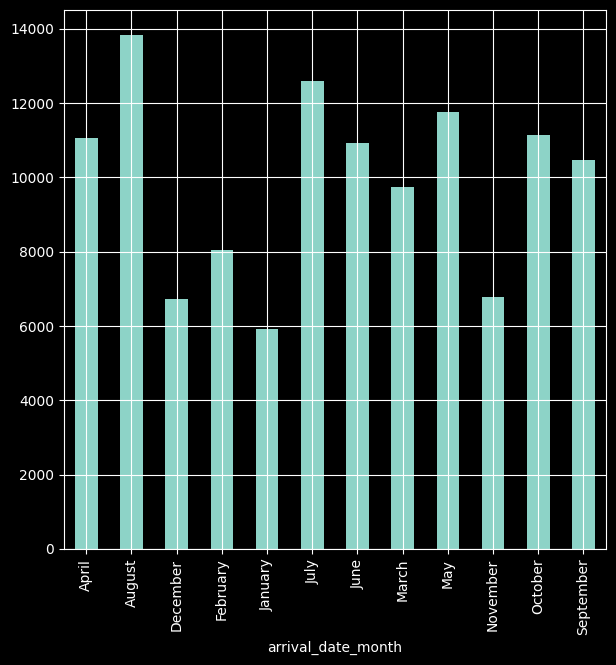

In [ ]:
month.hotel.plot(kind='bar',figsize=(7,7),grid=True)#graficando el mes

In [ ]:
x=df.groupby('hotel')['is_canceled'].value_counts()
#porcentaje de cancelado por ciudad hotel y resort
x

hotel         is_canceled
City Hotel    0              45921
              1              32988
Resort Hotel  0              28905
              1              11095
Name: count, dtype: int64

In [ ]:
print('percentage of cancellation of city hotel:',x[1]*100/(x[0]+x[1]))
print('percentage of cancellation of resort hotel :',x[3]*100/(x[2]+x[3]))
# numero de reservas por ciudad, hotel y resort

percentage of cancellation of city hotel: 41.80511728700148
percentage of cancellation of resort hotel : 27.7375


is_canceled
0    0.629271
1    0.370729
Name: proportion, dtype: float64


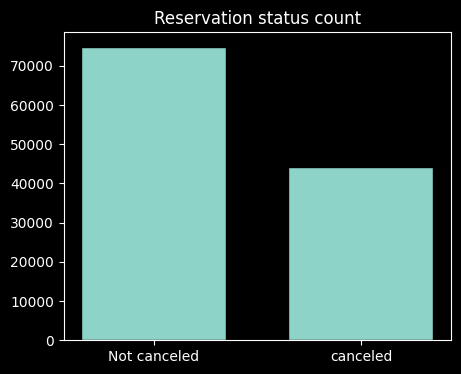

In [ ]:
cancelled_perc = df['is_canceled'].value_counts(normalize = True)
print(cancelled_perc)

plt.figure(figsize = (5,4))
plt.title('Reservation status count')
plt.bar(['Not canceled','canceled'],df['is_canceled'].value_counts(), edgecolor = 'k',width = 0.7)
plt.show()

Text(0, 0.5, 'number of reservaciones')

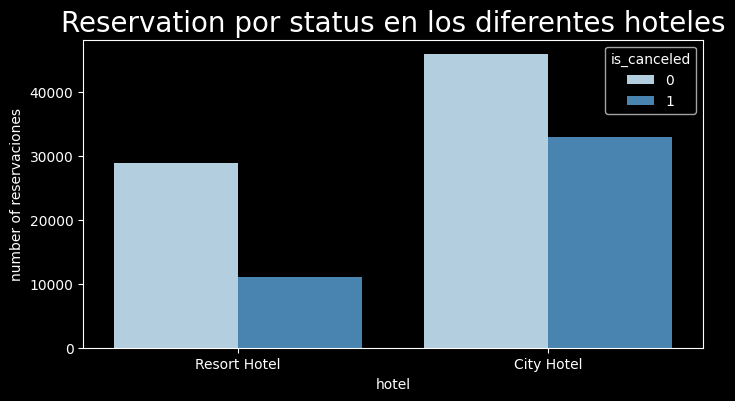

In [ ]:
plt.figure(figsize = (8,4))
ax1= sns.countplot(x = 'hotel', hue = 'is_canceled',data = df, palette = 'Blues')
legend_labels,_ = ax1. get_legend_handles_labels()
plt.title('Reservation por status en los diferentes hoteles',size = 20)
plt.xlabel('hotel')
plt.ylabel('number of reservaciones')

In [ ]:
#filtra por Resort Hotel los cancelados
resort_hotel = df[df['hotel'] == 'Resort Hotel']
resort_hotel['is_canceled'].value_counts(normalize = True)

,proportion
is_canceled,
0,0.722625
1,0.277375


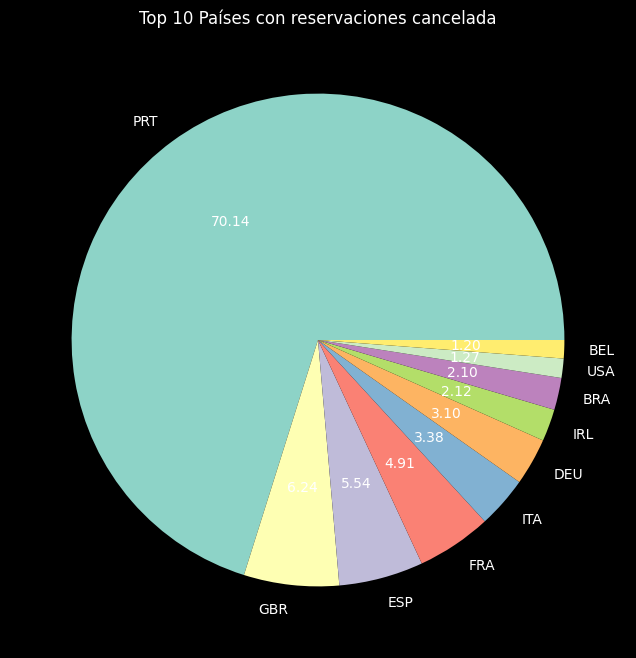

In [ ]:
cancelled_data = df[df['is_canceled'] == 1]
top_10_country = cancelled_data['country'].value_counts()[:10]
plt.figure(figsize = (8,8))
plt.title('Top 10 Países con reservaciones cancelada')
plt.pie(top_10_country,autopct = '%.2f',labels = top_10_country.index)
plt.show()

# **Codificaciones o conversiones necesarias para contar con más datos útiles acorde para los modelos**

In [ ]:
#Label Encoder
from sklearn.preprocessing import LabelEncoder
df['arrival_date_month_cod'] =LabelEncoder().fit_transform(df['arrival_date_month'])

In [ ]:
df['customer_type_cod']=LabelEncoder().fit_transform(df['customer_type'])

In [ ]:
df['reservation_status_cod']=LabelEncoder().fit_transform(df['reservation_status'])

In [ ]:
#Codificación ordinal
hotel_type = {'City Hotel':0,'Resort Hotel':1}
df['hotel'] = df['hotel'].map(hotel_type)

# **Correlación entre los atributos útil para aplicar algunos modelos**

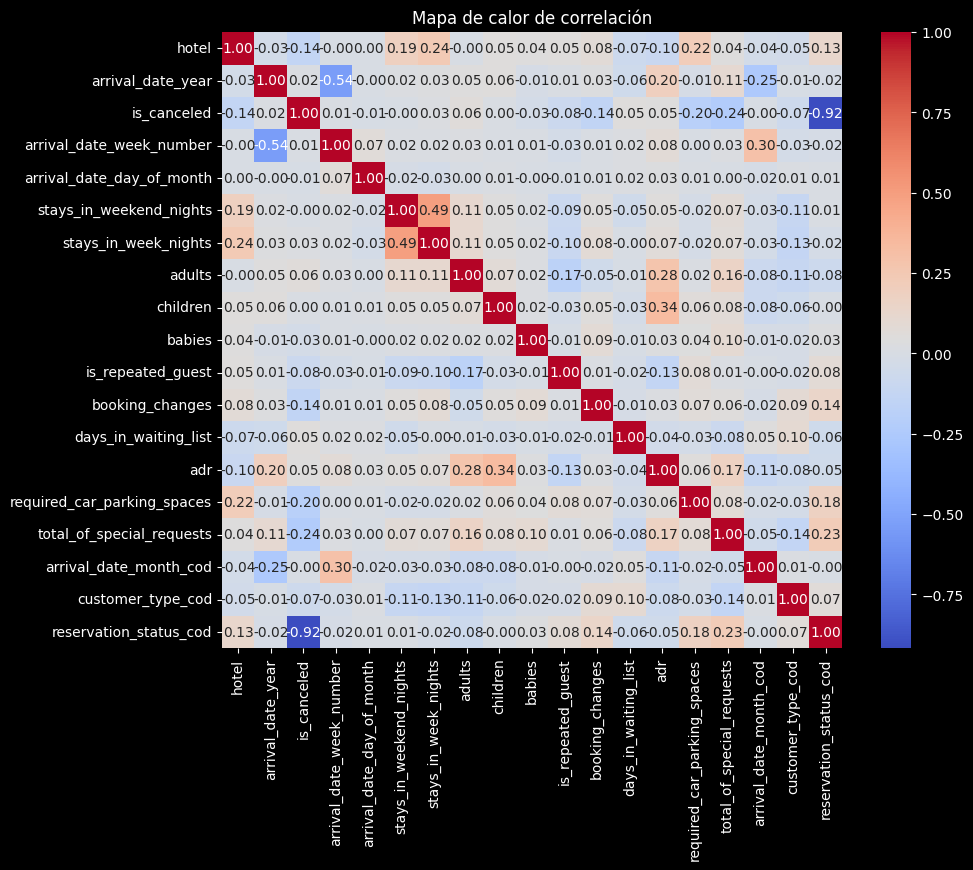

In [ ]:
def heatmap_correlacion(df):
    """
    Genera un mapa de calor con la correlación de variables numéricas.
    """
    # Seleccionar variables numéricas
    df_numeric = df.select_dtypes(include=['number'])

    # Calcular correlación
    corr = df_numeric.corr()

    # Graficar
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Mapa de calor de correlación')
    plt.show()


# Ejecución de la función

heatmap_correlacion(df)


El año de la fecha de llegada está fuertemente correlacionado con el la semana del año de llegada

# **Seleccionar los datos que se van a considerar para posteriores análisis**

In [ ]:
#Variables independientes X
X=df.drop(['is_canceled'],axis=1)

#Variable dependiente Y
y=df['is_canceled']

In [ ]:
print(X.head())

   hotel  arrival_date_year arrival_date_month  arrival_date_week_number  \
0      1               2015               July                        27   
1      1               2015               July                        27   
2      1               2015               July                        27   
3      1               2015               July                        27   
4      1               2015               July                        27   

   arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights  \
0                          1                        0                     0   
1                          1                        0                     0   
2                          1                        0                     1   
3                          1                        0                     1   
4                          1                        0                     2   

   adults  children  babies  ... booking_changes days_in_waiting_lis

In [ ]:
print(y.head())

0    0
1    0
2    0
3    0
4    0
Name: is_canceled, dtype: int64
